[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/07_linear_quadratic_conic_programs/first_principles.ipynb)

# Module 07 — Linear, Quadratic, and Conic Programs

## 1. Why This Module Exists

General nonlinear optimization is hard: a smooth function can hide exponentially many local minima, and no algorithm can certify global optimality without extra structure.
The escape route is to *restrict the algebraic form* of the objective and constraints until global optimality becomes checkable.

Convexity is the first restriction: a convex objective over a convex feasible set has no spurious local minima.
But convexity alone is still too loose for industrial-strength solvers.
The four classes studied here — **LP**, **QP**, **SOCP**, and **SDP** — restrict the form further, down to affine functions, positive semidefinite quadratics, norm cones, and matrix cones.
Each restriction buys three concrete things: a duality theory that issues certificates, a geometric characterization of where optima live, and a polynomial-time interior-point algorithm.

The oldest and most important of the four is the linear program.
Imagine allocating scarce resources: each decision variable $x_j \ge 0$ is a production level, each row of $Ax \le b$ is a resource budget, and the cost $c^\top x$ is linear because doubling production doubles cost.
Two observations drive the whole theory.
First, the feasible set $\{x : Ax \le b\}$ is an intersection of half-spaces — a **polyhedron**, a flat-sided convex body with finitely many corners.
Second, a nonconstant affine objective has a constant, nonzero gradient, so it always pays to keep sliding in the direction $-c$ until the boundary stops you.

What changes when the cost curves upward?
Adding a positive semidefinite quadratic term $\tfrac{1}{2}x^\top Q x$ produces the **QP** class, which captures least squares, ridge regression, support vector machines, and Markowitz portfolios.
Allowing constraints of the form "a norm of an affine expression is at most an affine expression" produces the **SOCP** class, which captures linear programming made robust against ellipsoidal data uncertainty.
Replacing scalar inequalities by the requirement that an affine *matrix-valued* function be positive semidefinite produces the **SDP** class, the most expressive tractable cone class known, powering control theory and combinatorial relaxations such as max-cut.

The payoff of the module is that these are not four unrelated formats but one nested chain,
$\text{LP} \subset \text{QP} \subset \text{SOCP} \subset \text{SDP}$,
witnessed by explicit, mechanical reformulations (Theorem 4.8, proved in Proof 5.8), and one conic template
$\min\{c^\top x : Ax = b,\ x \in \mathcal{K}\}$
that carries a single duality theory across all four (Theorem 4.7).
Knowing where a model sits tells you the cheapest solver class that can express it.

## 2. Intuition

**Tilting a plane over a polyhedron.**
Picture the graph of the affine cost $c^\top x$ as a rigid plane and the feasible set as a flat-sided stone.
Lowering the plane until it first touches the stone, the contact happens at a corner, at an edge, or along a whole face — but never strictly inside, because from an interior point one can always step a little in the direction $-c$ and go lower while staying feasible.
When the contact set is an edge or a face, it still contains a corner.
That is the entire content of the fundamental theorem of linear programming (Theorem 4.1): a continuous search over $\mathbb{R}^n$ collapses to a finite search over corners, which is why the simplex method can exist at all.

**Prices as certificates.**
If a resource budget $b_i$ is binding, someone would pay to relax it.
The dual variable $y_i$ is exactly that price, and the pairing $c^\top x - b^\top y = x^\top(c - A^\top y)$ is a nonnegative number whenever the primal plan is feasible and the price vector is "honest" (no activity is priced above its cost).
So any honest price vector certifies a lower bound on the cost, with no reference to the optimizer at all.
Optimality is the statement that a plan and a price vector make that nonnegative number zero — and since it is a sum of nonnegative terms, *each* term must vanish. That is complementary slackness.

**One cone, four classes.**
Replace "$x \ge 0$" by "$x$ lies in a closed convex cone $\mathcal{K}$" and the same pairing argument survives verbatim, provided the price vector lives in the *dual cone* $\mathcal{K}^\ast$.
Taking $\mathcal{K}$ to be the nonnegative orthant gives LP; the second-order cone gives SOCP; the cone of positive semidefinite matrices gives SDP.
Each of those three cones is its own dual (Theorem 4.6), so the primal and the dual look alike, and the same barrier-based algorithm solves all of them.

The two figures below make the two halves of this picture concrete: the first shows why an LP optimum lands on a corner, the second shows what kinds of feasible sets each level of the hierarchy can describe.

Setup: the shared preamble for every code cell in this notebook. All randomness is drawn from `rng`.

In [1]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

print("numpy", np.__version__)

numpy 2.4.6


**Figure 1.** The polyhedron $P = \{x \ge 0 : x_1 + x_2 \le 4,\ x_1 + 3x_2 \le 6\}$ with the level lines of the cost $c^\top x = -2x_1 - 3x_2$. The plot marks all four vertices and the one the cost selects; this is the instance carried through Example 6.1.

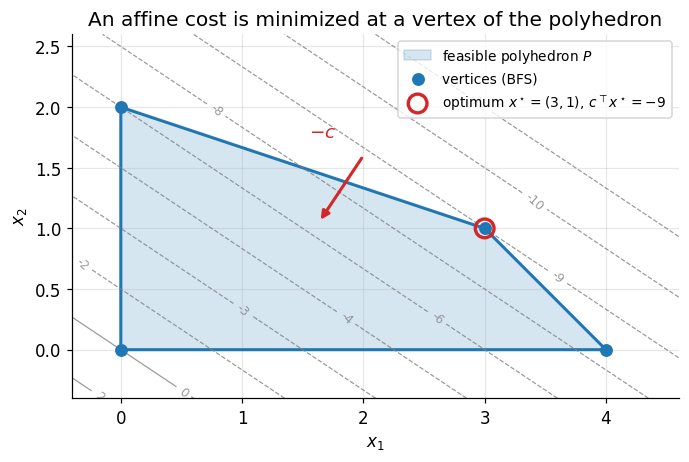

In [2]:
verts = np.array([[0.0, 0.0], [4.0, 0.0], [3.0, 1.0], [0.0, 2.0]])
c2 = np.array([-2.0, -3.0])

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.fill(verts[:, 0], verts[:, 1], color="tab:blue", alpha=0.18, label="feasible polyhedron $P$")
ax.plot(np.append(verts[:, 0], verts[0, 0]), np.append(verts[:, 1], verts[0, 1]),
        color="tab:blue", lw=2)

gx, gy = np.meshgrid(np.linspace(-0.4, 4.6, 300), np.linspace(-0.4, 2.6, 300))
cs = ax.contour(gx, gy, c2[0] * gx + c2[1] * gy,
                levels=np.arange(-12, 3, 1.5), colors="grey", linewidths=0.8, alpha=0.8)
ax.clabel(cs, fmt="%.0f", fontsize=8)

ax.scatter(verts[:, 0], verts[:, 1], s=55, color="tab:blue", zorder=3, label="vertices (BFS)")
ax.scatter([3.0], [1.0], s=150, facecolor="none", edgecolor="tab:red", lw=2.2, zorder=4,
           label=r"optimum $x^\star=(3,1)$, $c^\top x^\star=-9$")
ax.annotate("", xy=(2.0 + 0.55 * c2[0] / 3, 1.6 + 0.55 * c2[1] / 3), xytext=(2.0, 1.6),
            arrowprops=dict(arrowstyle="-|>", color="tab:red", lw=2))
ax.text(1.55, 1.75, r"$-c$", color="tab:red", fontsize=12)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("An affine cost is minimized at a vertex of the polyhedron")
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

The cost decreases in the direction $-c$; the last feasible point met is the corner $(3,1)$, not an interior point. Example 6.1 recomputes this by enumerating the basic feasible solutions and by calling a library solver.

**Figure 2.** What each level of the hierarchy can *describe*. All three sets below are convex, but only the square is an intersection of finitely many half-spaces (LP), only the square and the ellipse have quadratic descriptions (QP/SOCP), while the spectrahedron
$\{(x_1,x_2) : F(x_1,x_2) \succeq 0\}$ with
$F = \begin{bmatrix} 1 & x_1 & x_2 \\ x_1 & 1 & x_1 \\ x_2 & x_1 & 1\end{bmatrix}$
has a boundary that is neither flat nor an ellipse.

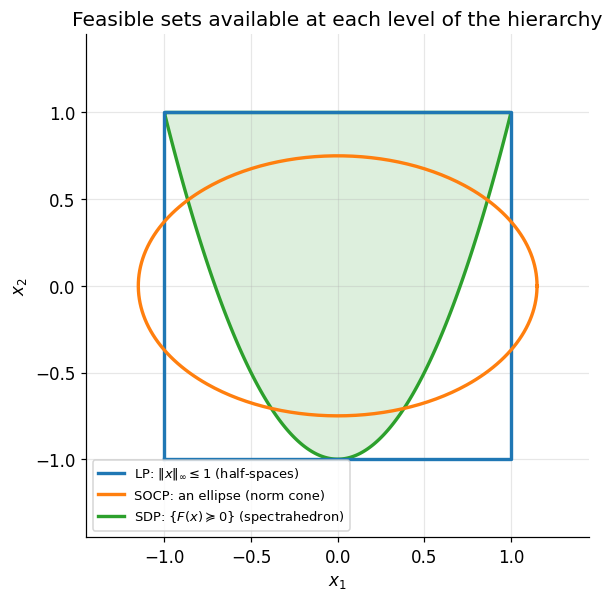

spectrahedron: lambda_min at (0,0) = 1.0
boundary point on the x_1-axis near 1/sqrt(2): 0.707107  1/sqrt(2) = 0.707107


In [3]:
gx, gy = np.meshgrid(np.linspace(-1.45, 1.45, 401), np.linspace(-1.45, 1.45, 401))
F = np.empty(gx.shape + (3, 3))
F[..., 0, 0] = F[..., 1, 1] = F[..., 2, 2] = 1.0
F[..., 0, 1] = F[..., 1, 0] = F[..., 1, 2] = F[..., 2, 1] = gx
F[..., 0, 2] = F[..., 2, 0] = gy
lam_min = np.linalg.eigvalsh(F)[..., 0]

fig, ax = plt.subplots(figsize=(6.0, 5.6))
ax.contourf(gx, gy, lam_min, levels=[0.0, lam_min.max()], colors=["tab:green"], alpha=0.16)
ax.contour(gx, gy, lam_min, levels=[0.0], colors="tab:green", linewidths=2.2)
ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], color="tab:blue", lw=2.2)
th = np.linspace(0, 2 * np.pi, 400)
ax.plot(1.15 * np.cos(th), 0.75 * np.sin(th), color="tab:orange", lw=2.2)

ax.plot([], [], color="tab:blue", lw=2.2, label=r"LP: $\|x\|_\infty \leq 1$ (half-spaces)")
ax.plot([], [], color="tab:orange", lw=2.2, label="SOCP: an ellipse (norm cone)")
ax.plot([], [], color="tab:green", lw=2.2, label=r"SDP: $\{F(x) \succeq 0\}$ (spectrahedron)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Feasible sets available at each level of the hierarchy")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
plt.show()

print("spectrahedron: lambda_min at (0,0) =", round(float(lam_min[200, 200]), 4))
print("boundary point on the x_1-axis near 1/sqrt(2):",
      round(float(np.interp(0.0, -lam_min[200, 200:], gx[200, 200:])), 6),
      " 1/sqrt(2) =", round(float(1 / np.sqrt(2)), 6))

The spectrahedron crosses the $x_1$-axis at $1/\sqrt{2}$, because $F(x_1, 0)$ has determinant $1 - 2x_1^2$. Its boundary is a cubic curve, so no finite set of half-spaces and no single ellipse reproduces it — a concrete reason the ladder does not stop at SOCP.

## 3. Definitions

### Definition 3.1 (Linear program: inequality and standard forms)

A *linear program* in **inequality form** is

$$
\min_{x \in \mathbb{R}^n} \ c^\top x \quad \text{subject to} \quad Ax \le b ,
$$

with $c \in \mathbb{R}^n$, $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$.
A linear program in **standard form** is

$$
\min_{x \in \mathbb{R}^n} \ c^\top x \quad \text{subject to} \quad Ax = b, \quad x \ge 0 .
$$

The two forms are interconvertible by two mechanical constructions:

- **Slack variables**: each inequality $a_i^\top x \le b_i$ becomes the pair $a_i^\top x + s_i = b_i$, $s_i \ge 0$; the new variable $s_i$ measures the unused budget of constraint $i$.
- **Free-variable splitting**: an unrestricted variable $x_j$ is replaced by $x_j = x_j^+ - x_j^-$ with $x_j^+ \ge 0$ and $x_j^- \ge 0$.

Both maps are bijections between feasible sets that preserve the objective, so the optimal value is unchanged; they only re-parameterize the geometry.

### Definition 3.2 (Polyhedron, extreme point, basic feasible solution)

A *polyhedron* is any set of the form $P = \{x \in \mathbb{R}^n : Ax \le b\}$; it is convex because it is an intersection of half-spaces.

A point $v \in P$ is an *extreme point* (vertex) if it cannot be written as $v = \tfrac{1}{2}(y + z)$ with $y, z \in P$ and $y \neq z$.

For the standard-form feasible set $\mathcal{F} = \{x : Ax = b,\ x \ge 0\}$ with $A \in \mathbb{R}^{m \times n}$ of full row rank, a *basic feasible solution* (BFS) is a feasible $x$ whose support $S = \{j : x_j \gt 0\}$ indexes linearly independent columns $\{A_j : j \in S\}$.
Equivalently, select a basis $B$ of $m$ independent columns, set the nonbasic variables to zero, and solve $A_B x_B = b$; the BFS is feasible when $x_B \ge 0$.
There are at most $\binom{n}{m}$ of them, so a polyhedron in standard form has finitely many extreme points.

### Definition 3.3 (Quadratic program)

A *quadratic program* is

$$
\min_{x \in \mathbb{R}^n} \ \tfrac{1}{2} x^\top Q x + c^\top x \quad \text{subject to} \quad Ax \le b, \quad Ex = d ,
$$

where $Q = Q^\top \succeq 0$.
Positive semidefiniteness of $Q$ is exactly the condition making the objective convex; an indefinite $Q$ yields a problem that is NP-hard in general.

*Least squares is the canonical unconstrained QP.* Expanding the residual norm of a linear model $Xw \approx y$,

$$
\tfrac{1}{2}\lVert Xw - y \rVert_2^2 = \tfrac{1}{2} w^\top (X^\top X) w - (X^\top y)^\top w + \tfrac{1}{2} y^\top y ,
$$

identifies $Q = X^\top X \succeq 0$ and $c = -X^\top y$.

*Markowitz portfolio selection is the canonical constrained QP*: minimize portfolio variance $w^\top \Sigma w$ subject to a target return $\mu^\top w \ge R$ and the budget $\mathbf{1}^\top w = 1$, where $\Sigma \succeq 0$ is the return covariance.

### Definition 3.4 (Second-order cone and SOCP)

The *second-order cone* (Lorentz cone, ice-cream cone) in $\mathbb{R}^{k+1}$ is

$$
\mathcal{Q}^{k+1} = \{(u, t) \in \mathbb{R}^k \times \mathbb{R} : \lVert u \rVert_2 \le t\} .
$$

A *second-order cone program* is

$$
\min_{x} \ f^\top x \quad \text{subject to} \quad \lVert A_i x + b_i \rVert_2 \le c_i^\top x + d_i, \quad i = 1, \dots, m ,
$$

that is, each constraint requires the affine image $(A_i x + b_i,\ c_i^\top x + d_i)$ to lie in a second-order cone.
Taking $A_i = 0$ recovers ordinary linear inequalities, so every LP is an SOCP.

*Robust LP as SOCP.* Suppose a constraint row $a^\top x \le b$ has an uncertain coefficient vector $a \in \mathcal{E} = \{\bar{a} + P u : \lVert u \rVert_2 \le 1\}$ and we demand feasibility for *every* realization. The worst case is

$$
\max_{\lVert u \rVert_2 \le 1} (\bar{a} + P u)^\top x = \bar{a}^\top x + \lVert P^\top x \rVert_2 ,
$$

so the robust constraint is exactly the second-order cone constraint $\bar{a}^\top x + \lVert P^\top x \rVert_2 \le b$.
Immunizing an LP against ellipsoidal data uncertainty therefore promotes it one level up the hierarchy.

### Definition 3.5 (Semidefinite program and LMI)

Let $\mathbb{S}^n$ denote symmetric $n \times n$ matrices and $X \succeq 0$ mean $X$ is positive semidefinite.
A *semidefinite program* in standard primal form is

$$
\min_{X \in \mathbb{S}^n} \ \operatorname{tr}(C X) \quad \text{subject to} \quad \operatorname{tr}(A_i X) = b_i \ (i = 1, \dots, m), \quad X \succeq 0 .
$$

The inequality-form counterpart uses a *linear matrix inequality* (LMI): $F(x) = F_0 + x_1 F_1 + \dots + x_n F_n \succeq 0$ with symmetric data matrices $F_j$.
The feasible set of an LMI, called a *spectrahedron*, is convex because the PSD cone is convex and $F$ is affine.

*Max-cut relaxation.* For a graph with weights $w_{ij}$, max-cut maximizes $\tfrac{1}{2}\sum_{i \lt j} w_{ij}(1 - x_i x_j)$ over labels $x_i \in \{-1, +1\}$.
Writing $X = x x^\top$ and dropping the rank-one requirement leaves the SDP relaxation: maximize $\tfrac{1}{2}\sum_{i \lt j} w_{ij}(1 - X_{ij})$ subject to $X_{ii} = 1$ and $X \succeq 0$, the basis of the Goemans-Williamson $0.878$ approximation guarantee.

### Definition 3.6 (Convex cone, dual cone, conic program)

A set $\mathcal{K} \subseteq \mathbb{R}^n$ is a *convex cone* if $\alpha u + \beta v \in \mathcal{K}$ whenever $u, v \in \mathcal{K}$ and $\alpha, \beta \ge 0$.
Its *dual cone* is

$$
\mathcal{K}^\ast = \{ s \in \mathbb{R}^n : s^\top x \ge 0 \ \text{ for all } x \in \mathcal{K} \} ,
$$

the set of linear functionals that are nonnegative on $\mathcal{K}$; $\mathcal{K}^\ast$ is a closed convex cone for any $\mathcal{K}$, being an intersection of half-spaces through the origin.
A *conic program* over a closed convex cone $\mathcal{K}$ is the pair

$$
p^\star = \min_{x} \ c^\top x \ \text{ s.t. } \ Ax = b, \ x \in \mathcal{K} ,
\qquad
d^\star = \max_{y} \ b^\top y \ \text{ s.t. } \ c - A^\top y \in \mathcal{K}^\ast .
$$

With $\mathcal{K} = \mathbb{R}^n_+$ this is exactly the standard-form LP and its dual; with $\mathcal{K}$ a product of second-order cones it is an SOCP; with $\mathcal{K} = \mathbb{S}^n_+$ and the trace inner product it is an SDP.
The program is *strictly feasible* (satisfies **Slater's condition**) if some feasible $x$ lies in the interior of $\mathcal{K}$.

## 4. Main Results

### Theorem 4.1 (Fundamental theorem of linear programming)

Let $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$, $c \in \mathbb{R}^n$, let $\mathcal{F} = \{x : Ax = b,\ x \ge 0\}$ be nonempty, and suppose $\min\{c^\top x : x \in \mathcal{F}\}$ is *attained* at some feasible point.
Then it is attained at an extreme point of $\mathcal{F}$, so an optimal solution can be found among the at most $\binom{n}{m}$ basic feasible solutions.

*Why each hypothesis is needed.* Nonemptiness rules out the vacuous infeasible case, where there is nothing to attain. Attainment cannot be dropped in general form: $\min\{-x_1 : x \ge 0\}$ is unbounded below and has no optimal point at all, extreme or otherwise. (For standard-form polyhedra a finite optimal value is in fact always attained — Luenberger & Ye, §2.4 — so the hypothesis is only an honesty device, not a restriction.) The nonnegativity $x \ge 0$ is essential: over the affine set $\{x : Ax = b\}$ alone there are no extreme points at all when $A$ has a nontrivial null space.

### Theorem 4.2 (Farkas' lemma)

Let $A \in \mathbb{R}^{m \times n}$ and $b \in \mathbb{R}^m$. Exactly one of the following holds:

1. there exists $x \ge 0$ with $Ax = b$;
2. there exists $y \in \mathbb{R}^m$ with $A^\top y \le 0$ and $b^\top y \gt 0$.

*Why the hypotheses are so light.* Nothing beyond finiteness of $A$ is assumed, and that is the point: the proof (Proof 5.2) needs the cone $\{Ax : x \ge 0\}$ to be **closed**, which is true precisely because it is generated by *finitely many* columns. For infinitely generated cones the alternative can fail, so "finitely many columns" is doing real work.

### Theorem 4.3 (LP duality and complementary slackness)

For the primal-dual pair

$$
p^\star = \min\{c^\top x : Ax = b,\ x \ge 0\}, \qquad d^\star = \max\{b^\top y : A^\top y \le c\} \ \ (y \text{ free}),
$$

the following hold.

1. **Weak duality.** $b^\top y \le c^\top x$ for every primal-feasible $x$ and dual-feasible $y$; hence $d^\star \le p^\star$. No hypothesis at all beyond feasibility of the two points.
2. **Strong duality.** If $p^\star$ is finite then the dual is feasible, $d^\star$ is attained, and $p^\star = d^\star$. Finiteness is needed: if the primal is unbounded below the dual is infeasible, and $-\infty = -\infty$ is not an equality between attained values.
3. **Complementary slackness.** Feasible $x^\star, y^\star$ are both optimal if and only if $x_j^\star\,(c - A^\top y^\star)_j = 0$ for every $j$. The sign conditions $x \ge 0$ and $c - A^\top y \ge 0$ are what turn a vanishing *sum* into vanishing *terms*; without them the products could cancel.

Under nondegeneracy, $y_i^\star$ is the rate of change of $p^\star$ per unit change in $b_i$ — the *shadow price* of resource $i$.

*Remark.* Part 2 has no Slater-type condition: polyhedrality supplies the constraint qualification for free. This is what makes LP duality strictly better behaved than general conic duality (Theorem 4.7).

### Theorem 4.4 (QP optimality: unconstrained minimizer and the equality-constrained KKT system)

1. If $Q \succ 0$, the function $f(x) = \tfrac{1}{2} x^\top Q x + c^\top x$ has the unique global minimizer $x^\star = -Q^{-1}c$ with value $-\tfrac{1}{2}c^\top Q^{-1}c$. Strict positive definiteness is needed twice: for $Q^{-1}$ to exist, and for the quadratic penalty away from $x^\star$ to be *strictly* positive, which is what gives uniqueness. With $Q \succeq 0$ only, minimizers form an affine set when $c \in \operatorname{range}(Q)$ and none exists otherwise.
2. If $Q \succeq 0$ and $A$ has full row rank, then any $(x^\star, \lambda^\star)$ solving the KKT system

$$
\begin{bmatrix} Q & A^\top \\ A & 0 \end{bmatrix}
\begin{bmatrix} x^\star \\ \lambda^\star \end{bmatrix}
=
\begin{bmatrix} -c \\ b \end{bmatrix}
$$

gives a global minimizer of $\tfrac{1}{2}x^\top Q x + c^\top x$ subject to $Ax = b$. Convexity ($Q \succeq 0$) is what upgrades stationarity to global optimality; full row rank of $A$ makes $\lambda^\star$ unique and the constraints non-redundant. If in addition $z^\top Q z \gt 0$ for every $z \neq 0$ with $Az = 0$, the KKT matrix is nonsingular and $(x^\star, \lambda^\star)$ is unique.

### Theorem 4.5 (Schur complement lemma)

Let $M = \begin{bmatrix} A & B \\ B^\top & C \end{bmatrix}$ be symmetric with $A \succ 0$. Then

$$
M \succeq 0 \iff S := C - B^\top A^{-1} B \succeq 0 .
$$

*Why $A \succ 0$ cannot be weakened to $A \succeq 0$.* The proof block-diagonalizes $M$ by a congruence built from $A^{-1}$, which requires invertibility. Replacing $A^{-1}$ by the pseudoinverse breaks the equivalence: $M = \begin{bmatrix} 0 & 1 \\ 1 & 1\end{bmatrix}$ has $C - B^\top A^{+} B = 1 \ge 0$ yet $\lambda_{\min}(M) = (1-\sqrt{5})/2 \lt 0$. Section 7 runs this counterexample. (The correct generalization adds the range condition $\operatorname{range}(B) \subseteq \operatorname{range}(A)$.)

### Theorem 4.6 (Self-duality of the three workhorse cones)

With the standard inner products — $s^\top x$ on $\mathbb{R}^n$ and $\langle S, X\rangle = \operatorname{tr}(SX)$ on $\mathbb{S}^n$ —

$$
(\mathbb{R}^n_+)^\ast = \mathbb{R}^n_+, \qquad (\mathcal{Q}^{k+1})^\ast = \mathcal{Q}^{k+1}, \qquad (\mathbb{S}^n_+)^\ast = \mathbb{S}^n_+ .
$$

*Why the inner product is part of the statement.* Duality of cones is defined relative to a pairing; the PSD cone is self-dual under the trace inner product on **symmetric** matrices and would not be if one dualized inside all of $\mathbb{R}^{n \times n}$, where the skew part is annihilated.

### Theorem 4.7 (Conic duality)

Let $\mathcal{K} \subseteq \mathbb{R}^n$ be a closed convex cone and consider the pair of Definition 3.6.

1. **Weak duality holds unconditionally**: $c^\top x - b^\top y = (c - A^\top y)^\top x \ge 0$ for every primal-feasible $x$ and dual-feasible $y$, so $d^\star \le p^\star$. Closedness of $\mathcal{K}$ is not even needed here; only $x \in \mathcal{K}$ and $c - A^\top y \in \mathcal{K}^\ast$.
2. **Strong duality under Slater** *(cited, not proved here)*: if $p^\star$ is finite and the primal is strictly feasible — some feasible $x$ lies in $\operatorname{int}\mathcal{K}$ — then $d^\star = p^\star$ and the dual optimum is attained. Reference: Ben-Tal & Nemirovski, *Lectures on Modern Convex Optimization*, Lecture 2, Theorem 2.4.1 (Conic Duality Theorem); equivalently Boyd & Vandenberghe §5.9.1 with §5.3.2.

*Why Slater cannot be dropped.* Unlike LP (Theorem 4.3, part 2), a conic program with no interior feasible point can have $d^\star \lt p^\star$ or an unattained dual optimum; explicit SDP instances with a positive finite gap are in Vandenberghe & Boyd, *SIAM Review* 38(1), §4. The strongest special case this module proves in full is the polyhedral one, $\mathcal{K} = \mathbb{R}^n_+$, where Theorem 4.2 replaces Slater entirely.

### Theorem 4.8 (The convex hierarchy)

Every LP is a QP, every convex QP can be reformulated as an SOCP, and every SOCP can be reformulated as an SDP:

$$
\text{LP} \subseteq \text{QP} \subseteq \text{SOCP} \subseteq \text{SDP} ,
$$

each inclusion witnessed by an explicit affine reformulation that preserves the optimal value and lets the optimizer be read off (Proof 5.8).
The first two inclusions are **strict**: a QP with $Q \succ 0$ has ellipsoidal sublevel sets, which no finite intersection of half-spaces reproduces, so $\text{QP} \not\subseteq \text{LP}$; and $\min\{t : \lVert x \rVert_2 \le t\}$ has a feasible set whose boundary is a cone, not a quadric graph, so $\text{SOCP} \not\subseteq \text{QP}$.
The third inclusion is also strict but the proof is substantial — not every spectrahedron is a projection of a second-order-cone-representable set — and is *cited, not proved here*: Ben-Tal & Nemirovski, Lectures 2-3.

*Why the hypotheses matter.* "Convex QP" means $Q \succeq 0$; for indefinite $Q$ the second inclusion is false, since the epigraph trick would demand $\lVert Rx \rVert_2^2 \le s$ with $R$ complex. The SOCP-to-SDP step needs the constraint written with the *norm on the left*, $\lVert u \rVert_2 \le t$ with $t$ affine, because the arrow matrix encodes $t \ge 0$ automatically.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Among all optimal solutions, choose $x^\star$ with the *smallest number of positive components*, and let $S = \{j : x_j^\star \gt 0\}$ be its support.
We show the columns $\{A_j : j \in S\}$ are linearly independent, which makes $x^\star$ a basic feasible solution, hence an extreme point.

Suppose instead they are dependent: there exists $d \neq 0$ supported on $S$ with $Ad = 0$.
For small $\lvert\theta\rvert$ the point $x(\theta) = x^\star + \theta d$ satisfies $A x(\theta) = b$ and stays nonnegative, because every component of $x^\star$ on $S$ is strictly positive.

*Step 1: the direction is cost-neutral.*
The objective along the segment is $c^\top x(\theta) = c^\top x^\star + \theta\, c^\top d$.
If $c^\top d \neq 0$, choosing $\theta$ small with sign opposite to $c^\top d$ produces a feasible point of strictly smaller cost, contradicting optimality of $x^\star$.
Hence $c^\top d = 0$: every feasible point on the segment is also optimal.

*Step 2: slide until a component dies.*
Replacing $d$ by $-d$ if necessary, assume $d$ has at least one negative component (if $d \ge 0$ use $-d$; if both $d \ge 0$ and $-d \ge 0$ then $d = 0$, a contradiction).
Define

$$
\theta^\star = \min_{j : d_j \lt 0} \frac{x_j^\star}{-d_j} \gt 0 .
$$

At $\theta = \theta^\star$ the point $x(\theta^\star)$ is feasible, still optimal by Step 1, and has at least one more zero component than $x^\star$, contradicting the minimality of the support.

Therefore no such $d$ exists, the support columns are independent, and $x^\star$ is a basic feasible solution, i.e. an extreme point.

$$
\boxed{\text{If an LP attains its optimum, some extreme point of the feasible polyhedron is optimal.}}
$$

**Interpretation.** The optimal value can always be read off a finite list. The consequence is algorithmic: the simplex method never has to consider anything but vertices, and any exhaustive vertex enumeration — however impractical for large $n$ — is a correct LP solver, as Section 7 demonstrates against a library routine.

### Proof 5.2 (of Theorem 4.2)

*Step 0: the two alternatives cannot both hold.*
If $Ax = b$ with $x \ge 0$ and $A^\top y \le 0$, then $b^\top y = (Ax)^\top y = x^\top (A^\top y) \le 0$, contradicting $b^\top y \gt 0$.

*Step 1: the cone of the columns is closed.*
Let $C = \{Ax : x \ge 0\}$, the set of nonnegative combinations of the columns of $A$.
By Carathéodory's theorem for cones, every $u \in C$ is already a nonnegative combination of a *linearly independent* subfamily of columns: starting from any representation, a linear dependence among the used columns lets one drive some coefficient to zero without leaving $C$, exactly as in Step 2 of Proof 5.1.
Hence $C = \bigcup_{S} \{A_S z : z \ge 0\}$, a union over the finitely many independent column subsets $S$.
Each piece is the image of the closed set $\{z \ge 0\}$ under an injective linear map (injective because the columns in $S$ are independent), and such an image is closed; a finite union of closed sets is closed.
So $C$ is closed and convex.

*Step 2: separate.*
Suppose alternative 1 fails, i.e. $b \notin C$.
Since $C$ is nonempty, closed, and convex, the projection $z = \Pi_C(b)$ exists and is characterized by $(u - z)^\top (b - z) \le 0$ for all $u \in C$ (`optimization/01`, projection onto a convex set).
Put $y = z - b \neq 0$. The characterization reads $(u - z)^\top y \ge 0$ for all $u \in C$.

*Step 3: extract the certificate.*
$C$ is a cone containing $0$ and $2z$. Taking $u = 0$ gives $-z^\top y \ge 0$; taking $u = 2z$ gives $z^\top y \ge 0$; hence $z^\top y = 0$ and therefore $u^\top y \ge 0$ for every $u \in C$.
Applying this to $u = A_j$, each column, gives $A^\top y \ge 0$.
Finally $b = z - y$, so

$$
b^\top y = z^\top y - y^\top y = -\lVert y \rVert_2^2 \lt 0 .
$$

Replacing $y$ by $-y$ yields $A^\top y \le 0$ and $b^\top y \gt 0$: alternative 2 holds.

$$
\boxed{\ \{x \ge 0 : Ax = b\} = \varnothing \iff \exists\, y : A^\top y \le 0,\ b^\top y \gt 0 .\ }
$$

**Interpretation.** Infeasibility of a linear system is itself certifiable by a single vector: $y$ is a linear combination of the equations that is nonpositive on every variable yet demands a positive right-hand side. The consequence is that LP needs no Slater condition — the certificate that would otherwise come from an interior point comes from finiteness of the generating set instead. Exercise L3.4 turns this lemma into LP strong duality (Theorem 4.3, part 2).

### Proof 5.3 (of Theorem 4.3, parts 1 and 3)

*Step 1 (weak duality).*
Let $x$ be primal feasible and $y$ dual feasible. Then

$$
c^\top x - b^\top y = c^\top x - (Ax)^\top y = x^\top c - x^\top A^\top y = x^\top (c - A^\top y) .
$$

Both factors are componentwise nonnegative: $x \ge 0$ by primal feasibility and $c - A^\top y \ge 0$ by dual feasibility. A sum of products of nonnegative numbers is nonnegative, hence

$$
c^\top x - b^\top y = \sum_{j=1}^{n} x_j \,(c - A^\top y)_j \ \ge\ 0 .
$$

So every dual-feasible $y$ certifies the lower bound $b^\top y \le c^\top x$; in particular $d^\star \le p^\star$.

*Step 2 (complementary slackness).*
Suppose feasible $x^\star, y^\star$ achieve $c^\top x^\star = b^\top y^\star$. The sum above vanishes, and since every term is nonnegative, *each term is zero*: for all $j$, either $x_j^\star = 0$ or $(c - A^\top y^\star)_j = 0$.
Conversely, if each term vanishes the objectives are equal, and by Step 1 no feasible pair can do better, so both points are optimal.

*Step 3 (part 2 of Theorem 4.3).* Strong duality follows from Farkas' lemma (Theorem 4.2) applied to the system asserting "cost below $p^\star$ is feasible"; the derivation is carried out step by step in exercise L3.4 of this module and is not repeated here.

$$
\boxed{\,b^\top y \le c^\top x \ \text{ for all feasible pairs, with equality} \iff x_j^\star\,(c - A^\top y^\star)_j = 0 \ \ \forall j.\,}
$$

**Interpretation.** A positive primal variable forces its dual constraint to be tight — the activity is priced exactly at cost — and a slack dual constraint forces its primal variable to zero, since an unprofitable activity is unused. The consequence is a certificate you can check in $O(n)$ arithmetic: given a candidate pair, verifying feasibility and $n$ vanishing products proves optimality without re-solving anything.

### Proof 5.4 (of Theorem 4.4)

*Part 1, Step 1 (complete the square).* Since $Q \succ 0$, $Q^{-1}$ exists and

$$
f(x) = \tfrac{1}{2}\,(x + Q^{-1} c)^\top Q\, (x + Q^{-1} c) - \tfrac{1}{2}\, c^\top Q^{-1} c .
$$

Expanding the first term gives $\tfrac{1}{2} x^\top Q x + x^\top Q Q^{-1} c + \tfrac{1}{2} c^\top Q^{-1} Q Q^{-1} c = \tfrac{1}{2} x^\top Q x + c^\top x + \tfrac{1}{2} c^\top Q^{-1} c$; subtracting $\tfrac{1}{2} c^\top Q^{-1} c$ recovers $f(x)$ exactly.

*Part 1, Step 2 (read off the minimizer).* The second term is constant. The first is a $Q$-weighted squared norm: nonnegative for every $x$, and zero *only* at $x + Q^{-1}c = 0$. Hence $x^\star = -Q^{-1}c$ and $f(x^\star) = -\tfrac{1}{2} c^\top Q^{-1} c$, and any $x \neq x^\star$ pays the strictly positive penalty $\tfrac{1}{2}(x - x^\star)^\top Q (x - x^\star)$.

Applied to $f(w) = \tfrac{1}{2}\lVert X w - y \rVert_2^2$, where $Q = X^\top X$ and $c = -X^\top y$, stationarity $Qw + c = 0$ is the *normal equations* $(X^\top X)w = X^\top y$, and $Q \succ 0$ holds exactly when $X$ has full column rank.

*Part 2, Step 1 (stationarity).* Form $\mathcal{L}(x, \lambda) = \tfrac{1}{2} x^\top Q x + c^\top x + \lambda^\top (A x - b)$; a constrained minimizer must satisfy $\nabla_x \mathcal{L} = Q x + c + A^\top \lambda = 0$. Stacking this with $Ax = b$ gives the KKT system of the theorem.

*Part 2, Step 2 (sufficiency).* Let $(x^\star, \lambda^\star)$ solve the system and let $x$ be any feasible point, so $A(x - x^\star) = 0$. With $g = Qx^\star + c = -A^\top \lambda^\star$,

$$
f(x) - f(x^\star) = g^\top (x - x^\star) + \tfrac{1}{2}(x - x^\star)^\top Q (x - x^\star)
= -\lambda^{\star\top} A (x - x^\star) + \tfrac{1}{2}(x - x^\star)^\top Q (x - x^\star) \ \ge\ 0 ,
$$

since the first term vanishes on the feasible subspace and the second is nonnegative by $Q \succeq 0$. Hence $x^\star$ is a global constrained minimizer.

$$
\boxed{\;x^\star = -Q^{-1}c \ \ (Q \succ 0), \qquad \begin{bmatrix} Q & A^\top \\ A & 0 \end{bmatrix}\begin{bmatrix} x^\star \\ \lambda^\star \end{bmatrix} = \begin{bmatrix} -c \\ b \end{bmatrix}\;}
$$

**Interpretation.** A convex QP with only equality constraints is not an iterative problem at all: it is one symmetric indefinite linear solve. The consequence is that every interior-point method for the larger classes reduces, at each Newton step, to exactly this block system — which is why sparse factorizations of KKT matrices are the computational heart of Section 7.

### Proof 5.5 (of Theorem 4.5)

*Step 1 (block congruence).* With $A \succ 0$ define the invertible block-triangular matrix

$$
T = \begin{bmatrix} I & 0 \\ -B^\top A^{-1} & I \end{bmatrix} ,
\qquad\text{so that}\qquad
T M T^\top = \begin{bmatrix} A & 0 \\ 0 & C - B^\top A^{-1} B \end{bmatrix} .
$$

The $(2,2)$ block is $B^\top A^{-1} A A^{-1} B - B^\top A^{-1} B - B^\top A^{-1} B + C = C - B^\top A^{-1} B$, since the four block products contribute one $+B^\top A^{-1}B$ term and two $-B^\top A^{-1}B$ terms alongside $C$.

*Step 2 (congruence preserves semidefiniteness).* For any invertible $T$: given $v$, set $w = T^\top v$; then $v^\top (T M T^\top) v = w^\top M w$, and as $v$ ranges over all vectors so does $w$. Hence $M \succeq 0 \iff T M T^\top \succeq 0$.

*Step 3 (conclude).* A block-diagonal symmetric matrix is PSD if and only if each diagonal block is PSD. Since $A \succ 0$ already, $T M T^\top \succeq 0$ reduces exactly to $S \succeq 0$.

$$
\boxed{\,A \succ 0 \implies \big( M \succeq 0 \iff C - B^\top A^{-1} B \succeq 0 \big).\,}
$$

**Interpretation.** A quadratic-over-linear condition on a *vector* is equivalent to a linear condition on a *matrix*. The consequence is the engine of Proof 5.8: norm constraints become linear matrix inequalities, which is precisely how SOCP is absorbed into SDP.

### Proof 5.6 (of Theorem 4.6)

*Nonnegative orthant.* If $y \ge 0$ and $x \ge 0$ then $y^\top x = \sum_j y_j x_j \ge 0$, so $\mathbb{R}^n_+ \subseteq (\mathbb{R}^n_+)^\ast$. Conversely if $y \in (\mathbb{R}^n_+)^\ast$, test $x = e_j$ to get $y_j \ge 0$ for each $j$. Hence equality.

*Second-order cone.* Let $(u,t), (v,s) \in \mathcal{Q}^{k+1}$. By Cauchy-Schwarz, $u^\top v \ge -\lVert u\rVert_2\lVert v\rVert_2 \ge -ts$, so $u^\top v + ts \ge 0$ and $\mathcal{Q}^{k+1} \subseteq (\mathcal{Q}^{k+1})^\ast$.
Conversely let $(v,s) \notin \mathcal{Q}^{k+1}$, i.e. $\lVert v \rVert_2 \gt s$. If $v \ne 0$, choose the cone member $(u,t) = (-v/\lVert v\rVert_2,\ 1)$; then $u^\top v + t s = -\lVert v\rVert_2 + s \lt 0$, so $(v,s) \notin (\mathcal{Q}^{k+1})^\ast$. If $v = 0$ then $s \lt 0$ and the cone member $(0,1)$ already gives $s \lt 0$. Hence equality.

*PSD cone.* If $S \succeq 0$ and $X \succeq 0$, write $X = \sum_i \lambda_i v_i v_i^\top$ with $\lambda_i \ge 0$; then $\operatorname{tr}(SX) = \sum_i \lambda_i\, v_i^\top S v_i \ge 0$, so $\mathbb{S}^n_+ \subseteq (\mathbb{S}^n_+)^\ast$. Conversely if $S \in (\mathbb{S}^n_+)^\ast$, test $X = vv^\top \succeq 0$ to get $\operatorname{tr}(S vv^\top) = v^\top S v \ge 0$ for every $v$, i.e. $S \succeq 0$. Hence equality.

$$
\boxed{\ (\mathbb{R}^n_+)^\ast = \mathbb{R}^n_+, \qquad (\mathcal{Q}^{k+1})^\ast = \mathcal{Q}^{k+1}, \qquad (\mathbb{S}^n_+)^\ast = \mathbb{S}^n_+ .\ }
$$

**Interpretation.** For these three cones the dual program lives in the same geometry as the primal, so "price vector" and "plan" are objects of the same kind. The consequence is practical: one primal-dual interior-point code, with one barrier per cone, handles LP, SOCP, and SDP without separate dual machinery.

### Proof 5.7 (of Theorem 4.7, part 1)

Let $x$ be primal feasible ($Ax = b$, $x \in \mathcal{K}$) and $y$ dual feasible ($s := c - A^\top y \in \mathcal{K}^\ast$). Then

$$
c^\top x - b^\top y = c^\top x - (Ax)^\top y = x^\top (c - A^\top y) = s^\top x \ \ge\ 0 ,
$$

the last inequality being the *definition* of $\mathcal{K}^\ast$ applied to $s \in \mathcal{K}^\ast$ and $x \in \mathcal{K}$.
Taking the infimum over $x$ and the supremum over $y$ gives $d^\star \le p^\star$.
Setting $\mathcal{K} = \mathbb{R}^n_+$ and using $(\mathbb{R}^n_+)^\ast = \mathbb{R}^n_+$ (Theorem 4.6) recovers Step 1 of Proof 5.3 verbatim, so LP weak duality is the orthant case of this one line.

Part 2 of Theorem 4.7 is cited, not proved here (Ben-Tal & Nemirovski, Lecture 2, Theorem 2.4.1). The polyhedral special case is proved in full: Theorem 4.2 plus exercise L3.4.

$$
\boxed{\ c^\top x - b^\top y = s^\top x \ge 0 \quad\text{for } x \in \mathcal{K},\ s = c - A^\top y \in \mathcal{K}^\ast .\ }
$$

**Interpretation.** The duality gap of a conic program is a single cone pairing $s^\top x$, and it is zero exactly when $x$ and $s$ are *complementary* — orthogonal members of $\mathcal{K}$ and $\mathcal{K}^\ast$. The consequence is that every interior-point method drives $s^\top x$ toward zero along a path where $s^\top x = \nu/t$ for a cone-dependent constant $\nu$, which Section 7 measures for the orthant, where $\nu = n$.

### Proof 5.8 (of Theorem 4.8)

*Step 1 (LP $\subseteq$ QP).* Set $Q = 0$ in $\tfrac{1}{2}x^\top Q x + c^\top x$: the zero matrix is symmetric and PSD, and the objective degenerates to $c^\top x$ with the same linear constraints. Hence every LP is a QP.

*Step 2 (convex QP $\subseteq$ SOCP).* Given $\min\ \tfrac{1}{2} x^\top Q x + c^\top x$ with $Q \succeq 0$, factor $Q = R^\top R$ with $R = Q^{1/2}$, the *symmetric square root* obtained from the eigendecomposition $Q = U\Lambda U^\top$ as $R = U\Lambda^{1/2}U^\top$; this exists for every $Q \succeq 0$, singular or not. (Cholesky is only a cheaper shortcut, and it requires $Q \succ 0$; on a singular PSD matrix it fails without pivoting, so the eigen square root is the construction that proves the theorem.)
Introduce an epigraph scalar $s$:

$$
\min_{x,\,s} \ \tfrac{1}{2} s + c^\top x \quad \text{subject to} \quad \lVert R x \rVert_2^2 \le s .
$$

At any optimum the constraint is tight, so the value is unchanged. Turn it into a cone constraint with the *rotated-cone identity*: for any vector $u$ and scalars $a, b \ge 0$,

$$
\lVert u \rVert_2^2 \le a\,b \iff \left\lVert \begin{bmatrix} 2u \\ a - b \end{bmatrix} \right\rVert_2 \le a + b ,
$$

which follows by squaring: $4\lVert u\rVert_2^2 + (a-b)^2 \le (a+b)^2 \iff 4\lVert u\rVert_2^2 \le 4ab$.
Apply it with $u = Rx$, $a = s$, $b = 1$: the epigraph constraint becomes $\lVert (2Rx,\ s - 1) \rVert_2 \le s + 1$, whose entries are affine in $(x,s)$. All original linear constraints stay linear, so the whole problem is an SOCP.

*Step 3 (SOCP $\subseteq$ SDP).* It suffices to write one cone constraint $\lVert u \rVert_2 \le t$, with $u = Ax + b$ and $t = c^\top x + d$ affine, as an LMI. Consider the *arrow matrix*

$$
M(u, t) = \begin{bmatrix} t I_k & u \\ u^\top & t \end{bmatrix} \in \mathbb{S}^{k+1} .
$$

If $t \gt 0$, Theorem 4.5 applied to the block $tI_k \succ 0$ gives $M \succeq 0 \iff t - u^\top (tI)^{-1} u \ge 0 \iff t^2 \ge \lVert u \rVert_2^2 \iff \lVert u \rVert_2 \le t$.
If $t = 0$, then $M \succeq 0$ forces $u = 0$: testing $M$ against $(w, \tau)$ gives $2\tau\, u^\top w \ge 0$ for all $w$ and both signs of $\tau$, which is possible only for $u = 0$ — matching $\lVert u \rVert_2 \le 0$.
If $t \lt 0$ both conditions fail, since the diagonal of a PSD matrix is nonnegative.
Because $M(u,t)$ is affine in $x$, the constraint is an LMI and the SOCP is an SDP.

*Step 4 (strictness of the first two inclusions).* If $\text{QP} \subseteq \text{LP}$ held, the sublevel set $\{x : x^\top x \le 1\}$ — a QP sublevel set — would be an intersection of finitely many half-spaces. But a polyhedron with nonempty interior has a boundary containing a line segment, while every boundary point of the Euclidean ball is an extreme point of the ball; so no polyhedron equals the ball, and $\text{QP} \not\subseteq \text{LP}$. Similarly $\{(x,t) : \lVert x \rVert_2 \le t\}$ has a boundary that is positively homogeneous with a vertex at the origin, which no sublevel set of a *strictly* convex quadratic can match, giving $\text{SOCP} \not\subseteq \text{QP}$. Strictness of $\text{SOCP} \subseteq \text{SDP}$ is cited above, not proved here.

$$
\boxed{\text{LP} \subseteq \text{QP} \subseteq \text{SOCP} \subseteq \text{SDP}, \ \text{each inclusion witnessed by an explicit affine embedding.}}
$$

**Interpretation.** Every model in this module can be handed to an SDP solver, and every model can be *diagnosed* by asking which is the lowest level that expresses it. The consequence is a modeling discipline: descend the chain whenever possible, because per-iteration cost grows from a sparse orthant solve (LP) to a dense eigen-factorization (SDP), and Example 6.2 shows the descent and ascent explicitly on a $2 \times 2$ instance.

## 6. Worked Examples

### Example 6.1 (Theorems 4.1, 4.2 and 4.3 on a four-variable LP)

Take the production problem of Figure 1 in standard form. With slacks $s_1, s_2$ and $x = (x_1, x_2, s_1, s_2)$,

$$
A = \begin{bmatrix} 1 & 1 & 1 & 0 \\ 1 & 3 & 0 & 1 \end{bmatrix},
\qquad b = \begin{bmatrix} 4 \\ 6 \end{bmatrix},
\qquad c = \begin{bmatrix} -2 \\ -3 \\ 0 \\ 0 \end{bmatrix} .
$$

**Step 1 (enumerate the bases).** Here $m = 2$, $n = 4$, so there are $\binom{4}{2} = 6$ candidate bases. Solving $A_B x_B = b$ for each:

| basis $B$ | $x_B$ | feasible? | $x$ | $c^\top x$ |
|---|---|---|---|---|
| $\{1,2\}$ | $x_1 = 3,\ x_2 = 1$ | yes | $(3,1,0,0)$ | $-9$ |
| $\{1,3\}$ | $x_1 = 6,\ s_1 = -2$ | no | — | — |
| $\{1,4\}$ | $x_1 = 4,\ s_2 = 2$ | yes | $(4,0,0,2)$ | $-8$ |
| $\{2,3\}$ | $x_2 = 2,\ s_1 = 2$ | yes | $(0,2,2,0)$ | $-6$ |
| $\{2,4\}$ | $x_2 = 4,\ s_2 = -6$ | no | — | — |
| $\{3,4\}$ | $s_1 = 4,\ s_2 = 6$ | yes | $(0,0,4,6)$ | $0$ |

For $B = \{1,2\}$: $x_1 + x_2 = 4$ and $x_1 + 3x_2 = 6$ subtract to $2x_2 = 2$, so $x_2 = 1$, $x_1 = 3$.
Four basic feasible solutions, and Theorem 4.1 says the smallest of the four values is the optimum: $p^\star = -9$ at $x^\star = (3,1,0,0)$.

**Step 2 (guess the dual from complementary slackness).** Since $x_1^\star \gt 0$ and $x_2^\star \gt 0$, Theorem 4.3 part 3 forces the first two dual constraints to be tight:

$$
y_1 + y_2 = -2, \qquad y_1 + 3y_2 = -3 .
$$

Subtracting gives $2y_2 = -1$, so $y_2 = -\tfrac{1}{2}$ and $y_1 = -\tfrac{3}{2}$. The remaining dual constraints, coming from the slack columns, read $y_1 \le 0$ and $y_2 \le 0$: both hold, so $y^\star$ is dual feasible.

**Step 3 (check the value and the prices).** $b^\top y^\star = 4(-\tfrac{3}{2}) + 6(-\tfrac{1}{2}) = -6 - 3 = -9 = p^\star$, so the gap is zero and Theorem 4.3 is confirmed on this instance.
Reading $y^\star$ as shadow prices: one extra unit of resource 1 lowers the optimal cost by $\tfrac{3}{2}$, one extra unit of resource 2 by $\tfrac{1}{2}$.

**Step 4 (a Farkas certificate on a sibling system).** Theorem 4.2 says infeasibility is equally certifiable. Take

$$
\tilde A = \begin{bmatrix} 1 & 1 \\ 2 & 2 \end{bmatrix}, \qquad \tilde b = \begin{bmatrix} 1 \\ 3 \end{bmatrix} .
$$

Every $\tilde A x$ has second component twice the first, while $\tilde b$ does not, so $\{x \ge 0 : \tilde A x = \tilde b\}$ is empty. The certificate is $y = (-2, 1)$: it gives $\tilde A^\top y = (0,0) \le 0$ and $\tilde b^\top y = -2 + 3 = 1 \gt 0$, which is alternative 2 of Theorem 4.2. The code cell below checks both alternatives.

The next cell recomputes Example 6.1 three ways — vertex enumeration, a library LP solve, and the hand-derived dual — and asserts that the duality gap and every complementary-slackness product sit at machine-epsilon level.

In [4]:
A = np.array([[1.0, 1.0, 1.0, 0.0],
              [1.0, 3.0, 0.0, 1.0]])
b = np.array([4.0, 6.0])
c = np.array([-2.0, -3.0, 0.0, 0.0])
m, n = A.shape

rows = []
for B in itertools.combinations(range(n), m):
    AB = A[:, list(B)]
    if abs(np.linalg.det(AB)) < 1e-12:
        continue
    xB = np.linalg.solve(AB, b)
    x = np.zeros(n)
    x[list(B)] = xB
    rows.append((B, x.copy(), float(c @ x), bool((xB >= -1e-12).all())))

for B, x, val, feas in rows:
    print(f"basis {B}  x = {x}  c^T x = {val:7.3f}  feasible = {feas}")

bfs = [(x, val) for _, x, val, feas in rows if feas]
x_enum, p_enum = min(bfs, key=lambda r: r[1])

res = linprog(c, A_eq=A, b_eq=b, bounds=[(0, None)] * n, method="highs")
y_hand = np.array([-1.5, -0.5])
gap = float(c @ res.x - b @ y_hand)
cs = res.x * (c - A.T @ y_hand)

print(f"\nvertex enumeration : x* = {x_enum}, p* = {p_enum:.6f}")
print(f"library (HiGHS)    : x* = {res.x}, p* = {res.fun:.6f}")
print(f"hand-derived dual  : y* = {y_hand}, d* = {b @ y_hand:.6f}")
print(f"duality gap |p*-d*|                     = {abs(gap):.3e}")
print(f"max complementary-slackness product     = {np.abs(cs).max():.3e}")

assert np.allclose(x_enum, res.x, atol=1e-9)
assert abs(gap) < 1e-9 and np.abs(cs).max() < 1e-9

# Theorem 4.2 in action: certify that {x >= 0 : Ax = b_bad} is empty.
A_bad = np.array([[1.0, 1.0], [2.0, 2.0]])
b_bad = np.array([1.0, 3.0])
y_cert = np.array([-2.0, 1.0])
print(f"\nFarkas certificate y = {y_cert}:  A^T y = {A_bad.T @ y_cert} (<= 0), "
      f"b^T y = {b_bad @ y_cert:.1f} (> 0)")
assert (A_bad.T @ y_cert <= 1e-12).all() and b_bad @ y_cert > 0

basis (0, 1)  x = [3. 1. 0. 0.]  c^T x =  -9.000  feasible = True
basis (0, 2)  x = [ 6.  0. -2.  0.]  c^T x = -12.000  feasible = False
basis (0, 3)  x = [4. 0. 0. 2.]  c^T x =  -8.000  feasible = True
basis (1, 2)  x = [0. 2. 2. 0.]  c^T x =  -6.000  feasible = True
basis (1, 3)  x = [ 0.  4.  0. -6.]  c^T x = -12.000  feasible = False
basis (2, 3)  x = [0. 0. 4. 6.]  c^T x =   0.000  feasible = True

vertex enumeration : x* = [3. 1. 0. 0.], p* = -9.000000
library (HiGHS)    : x* = [3. 1. 0. 0.], p* = -9.000000
hand-derived dual  : y* = [-1.5 -0.5], d* = -9.000000
duality gap |p*-d*|                     = 0.000e+00
max complementary-slackness product     = 0.000e+00

Farkas certificate y = [-2.  1.]:  A^T y = [0. 0.] (<= 0), b^T y = 1.0 (> 0)


Vertex enumeration and HiGHS return the same vertex $(3,1,0,0)$, the hand-derived dual matches it to $10^{-9}$, and every complementary-slackness product is zero at machine-epsilon level — Theorems 4.1 and 4.3 confirmed. The last two lines display a Farkas certificate: $y = (-2,1)$ satisfies $A^\top y \le 0$ while $b^\top y = 1 \gt 0$, proving the system $x \ge 0,\ Ax = b$ has no solution without ever attempting to solve it.

### Example 6.2 (Theorems 4.4, 4.5 and 4.8 on a $2 \times 2$ QP)

Minimize $f(x) = \tfrac{1}{2}x^\top Q x + c^\top x$ with

$$
Q = \begin{bmatrix} 5 & 3 \\ 3 & 5 \end{bmatrix} \succ 0, \qquad c = \begin{bmatrix} -8 \\ -8 \end{bmatrix} .
$$

**Step 1 (solve the QP by Theorem 4.4).** $\det Q = 25 - 9 = 16$, so $Q^{-1} = \tfrac{1}{16}\begin{bmatrix} 5 & -3 \\ -3 & 5\end{bmatrix}$ and

$$
x^\star = -Q^{-1}c = \tfrac{1}{16}\begin{bmatrix} 5 & -3 \\ -3 & 5\end{bmatrix}\begin{bmatrix} 8 \\ 8\end{bmatrix} = \begin{bmatrix} 1 \\ 1 \end{bmatrix},
\qquad f(x^\star) = \tfrac{1}{2}(16) - 16 = -8 .
$$

**Step 2 (the symmetric square root).** $Q$ has eigenvalues $8$ and $2$ with eigenvectors $\tfrac{1}{\sqrt2}(1,1)$ and $\tfrac{1}{\sqrt2}(1,-1)$, so

$$
R = Q^{1/2} = \tfrac{\sqrt2}{2}\begin{bmatrix} 3 & 1 \\ 1 & 3 \end{bmatrix},
\qquad R^\top R = \tfrac{1}{2}\begin{bmatrix} 10 & 6 \\ 6 & 10 \end{bmatrix} = Q .
$$

Then $R x^\star = \tfrac{\sqrt2}{2}(4,4) = (2\sqrt2,\, 2\sqrt2)$ and the epigraph variable is $s^\star = \lVert Rx^\star\rVert_2^2 = 8 + 8 = 16$. The SOCP objective reproduces the QP value: $\tfrac{1}{2}s^\star + c^\top x^\star = 8 - 16 = -8$.

**Step 3 (rotated-cone identity, exactly).** With $a = s^\star = 16$ and $b = 1$,

$$
\left\lVert \begin{bmatrix} 2Rx^\star \\ s^\star - 1 \end{bmatrix} \right\rVert_2
= \sqrt{(4\sqrt2)^2 + (4\sqrt2)^2 + 15^2} = \sqrt{32 + 32 + 225} = \sqrt{289} = 17 = s^\star + 1 .
$$

The cone constraint is *tight*, as it must be at a QP optimum.

**Step 4 (arrow matrix, Theorem 4.5).** Put $u = (4\sqrt2,\, 4\sqrt2,\, 15)$ and $t = 17$, so $\lVert u\rVert_2 = t$. The arrow matrix $M(u,t) \in \mathbb{S}^4$ has eigenvalues $t$ with multiplicity $k - 1 = 2$ and $t \pm \lVert u\rVert_2$:

$$
\operatorname{spec} M(u,t) = \{\,34,\ 17,\ 17,\ 0\,\} .
$$

The single zero eigenvalue is the SDP's way of recording that the second-order cone constraint holds with equality.

The next cell recomputes every number of Example 6.2 — the eigen square root, the epigraph value, the rotated-cone identity residual, and the arrow-matrix spectrum — and asserts each against the hand computation.

In [5]:
Q = np.array([[5.0, 3.0], [3.0, 5.0]])
c_qp = np.array([-8.0, -8.0])

lam, U = np.linalg.eigh(Q)
R = U @ np.diag(np.sqrt(lam)) @ U.T          # symmetric square root, valid for any Q >= 0
x_qp = np.linalg.solve(Q, -c_qp)
f_qp = 0.5 * x_qp @ Q @ x_qp + c_qp @ x_qp

s_star = float(R @ x_qp @ (R @ x_qp))
u_rot = np.concatenate([2.0 * (R @ x_qp), [s_star - 1.0]])
t_rot = s_star + 1.0
M = np.block([[t_rot * np.eye(3), u_rot.reshape(-1, 1)],
              [u_rot.reshape(1, -1), np.array([[t_rot]])]])
eig_M = np.linalg.eigvalsh(M)

print(f"eigenvalues of Q                 = {lam}")
print(f"R = Q^(1/2)                      =\n{R}")
print(f"residual ||R^T R - Q||_F         = {np.linalg.norm(R.T @ R - Q):.3e}")
print(f"x* = {x_qp},  f(x*) = {f_qp:.6f}")
print(f"epigraph s* = ||Rx*||^2          = {s_star:.6f}   (hand: 16)")
print(f"SOCP objective 0.5*s* + c^T x*   = {0.5 * s_star + c_qp @ x_qp:.6f}")
print(f"rotated-cone residual |lhs-rhs|  = {abs(np.linalg.norm(u_rot) - t_rot):.3e}")
print(f"arrow-matrix eigenvalues         = {eig_M}   (hand: 0, 17, 17, 34)")

assert np.linalg.norm(R.T @ R - Q) < 1e-12
assert abs(s_star - 16.0) < 1e-10 and abs(f_qp + 8.0) < 1e-12
assert abs(np.linalg.norm(u_rot) - t_rot) < 1e-10
assert np.allclose(np.sort(eig_M), [0.0, 17.0, 17.0, 34.0], atol=1e-9)

eigenvalues of Q                 = [2. 8.]
R = Q^(1/2)                      =
[[2.1213 0.7071]
 [0.7071 2.1213]]
residual ||R^T R - Q||_F         = 1.404e-15
x* = [1. 1.],  f(x*) = -8.000000
epigraph s* = ||Rx*||^2          = 16.000000   (hand: 16)
SOCP objective 0.5*s* + c^T x*   = -8.000000
rotated-cone residual |lhs-rhs|  = 3.553e-15
arrow-matrix eigenvalues         = [-0. 17. 17. 34.]   (hand: 0, 17, 17, 34)


Every residual — $\lVert R^\top R - Q\rVert_F$, the rotated-cone identity, the distance of the arrow spectrum from $\{0,17,17,34\}$ — sits at machine-epsilon level, so the chain QP $\to$ SOCP $\to$ SDP of Proof 5.8 preserves both the optimizer and the value on this instance.

### Example 6.3 (Theorems 4.6 and 4.7 on a conic program over $\mathcal{Q}^3$)

Take $\mathcal{K} = \mathcal{Q}^3 = \{(x_1,x_2,x_3) : \sqrt{x_1^2 + x_2^2} \le x_3\}$ and

$$
c = \begin{bmatrix} -1 \\ 0 \\ 0 \end{bmatrix}, \qquad A = \begin{bmatrix} 0 & 0 & 1\end{bmatrix}, \qquad b = 1 .
$$

**Step 1 (solve the primal by inspection).** The constraint $Ax = b$ pins $x_3 = 1$, and membership in $\mathcal{K}$ then says $x_1^2 + x_2^2 \le 1$. Minimizing $c^\top x = -x_1$ over the unit disc gives $x^\star = (1, 0, 1)$ and $p^\star = -1$.

**Step 2 (form the dual).** With $y \in \mathbb{R}$, the dual slack is $s = c - A^\top y = (-1,\,0,\,-y)$. By Theorem 4.6, $\mathcal{K}^\ast = \mathcal{Q}^3$, so dual feasibility reads $\lVert(-1,0)\rVert_2 \le -y$, i.e. $y \le -1$. Maximizing $b^\top y = y$ gives $y^\star = -1$ and $d^\star = -1$.

**Step 3 (check the gap and complementarity).** $p^\star = d^\star = -1$: no gap, as Theorem 4.7 part 2 predicts, and Slater holds because $x = (0,0,1)$ is feasible with $\lVert(0,0)\rVert_2 = 0 \lt 1$, hence interior to $\mathcal{K}$. The complementarity product is

$$
s^{\star\top} x^\star = (-1,\,0,\,1)^\top (1,\,0,\,1) = -1 + 0 + 1 = 0 ,
$$

confirming the boxed identity of Proof 5.7 with equality.

The next cell verifies Example 6.3 and then tests Theorem 4.6 statistically: sampled pairs inside $\mathcal{Q}^{k+1}$ must pair nonnegatively, and every sampled point outside the cone must be exposed by some cone member with a strictly negative pairing.

In [6]:
A_c = np.array([[0.0, 0.0, 1.0]])
b_c = np.array([1.0])
c_c = np.array([-1.0, 0.0, 0.0])
x_c = np.array([1.0, 0.0, 1.0])
y_c = np.array([-1.0])
s_c = c_c - A_c.T @ y_c

print(f"primal value c^T x*   = {c_c @ x_c:.6f}   (feasible: Ax-b = {A_c @ x_c - b_c})")
print(f"dual   value b^T y*   = {b_c @ y_c:.6f}   (s = c - A^T y = {s_c})")
print(f"x* in K  : {np.linalg.norm(x_c[:2]) <= x_c[2] + 1e-12}")
print(f"s* in K* : {np.linalg.norm(s_c[:2]) <= s_c[2] + 1e-12}")
print(f"complementarity s*^T x* = {s_c @ x_c:.3e}")
assert abs(c_c @ x_c - b_c @ y_c) < 1e-12 and abs(s_c @ x_c) < 1e-12

k, trials = 3, 20000
u = rng.normal(size=(trials, k))
t = rng.uniform(0.0, np.linalg.norm(u, axis=1).max() + 2.0, size=trials)
inside = t >= np.linalg.norm(u, axis=1)
idx_in, idx_out = np.flatnonzero(inside), np.flatnonzero(~inside)
half = len(idx_in) // 2
i1, i2 = idx_in[:half], idx_in[half:2 * half]

pair_in = np.einsum("ij,ij->i", u[i1], u[i2]) + t[i1] * t[i2]
nrm = np.linalg.norm(u[idx_out], axis=1)
witness = -np.einsum("ij,ij->i", u[idx_out], u[idx_out]) / nrm + t[idx_out]

print(f"\nin-cone pairs with <x,y> >= 0            : {(pair_in >= -1e-12).mean():.6f} (must be 1.0)")
print(f"out-of-cone points exposed by a witness  : {(witness < 0).mean():.6f} (must be 1.0)")
assert (pair_in >= -1e-12).all() and (witness < 0).all()

primal value c^T x*   = -1.000000   (feasible: Ax-b = [0.])
dual   value b^T y*   = -1.000000   (s = c - A^T y = [-1.  0.  1.])
x* in K  : True
s* in K* : True
complementarity s*^T x* = 0.000e+00

in-cone pairs with <x,y> >= 0            : 1.000000 (must be 1.0)
out-of-cone points exposed by a witness  : 1.000000 (must be 1.0)


The conic pair closes exactly ($p^\star = d^\star = -1$, complementarity $0$), and $20\,000$ samples reproduce Theorem 4.6: no in-cone pair ever pairs negatively, and each of the sampled points outside $\mathcal{Q}^4$ is exposed by the explicit witness $(-u/\lVert u\rVert_2,\,1)$ built in Proof 5.6.

## 7. Computational Practice

### 7.1 The simplex method: a combinatorial edge walk

Theorem 4.1 licenses searching only vertices. The simplex method (Dantzig, 1947) organizes that search:

1. Start at a basic feasible solution, found by an auxiliary *phase one* LP that minimizes the total artificial infeasibility.
2. Compute *reduced costs* of the nonbasic variables; if all are nonnegative the current vertex is optimal, and the reduced-cost vector is exactly the complementary-slackness certificate of Theorem 4.3.
3. Otherwise bring a negative-reduced-cost variable into the basis and slide along the corresponding edge until the *ratio test* drives a basic variable to zero; pivot and repeat.

Each pivot costs $O(mn)$ arithmetic on the tableau, or one rank-one update of a factorization.
Empirically the method finishes in $O(m)$ to $O(m+n)$ pivots, but the **Klee-Minty cube** forces $2^n$ pivots under the classical pivot rule; smoothed analysis (Spielman-Teng) explains the gap, since tiny random perturbations of any instance make the expected pivot count polynomial.
Degeneracy — a vertex with more than $n - m$ zero components — can stall the walk, and anti-cycling rules such as Bland's rule guarantee termination.

### 7.2 Interior-point and barrier methods: the analytic route

Interior-point methods ignore vertices. Replace $x \ge 0$ by a *logarithmic barrier*:

$$
\min_x \ t\, c^\top x - \sum_{j=1}^{n} \ln x_j \quad \text{subject to} \quad Ax = b .
$$

For each $t \gt 0$ the minimizer $x(t)$ is strictly interior; the curve $\{x(t) : t \gt 0\}$ is the **central path**.
Stationarity of the barrier problem reads $tc - x^{-1} + A^\top w = 0$ for a multiplier $w$; setting $y(t) = -w/t$ gives $c - A^\top y(t) = x(t)^{-1}/t \gt 0$, so $y(t)$ is *dual feasible*, and the duality gap is

$$
c^\top x(t) - b^\top y(t) \;=\; x(t)^\top\!\left(c - A^\top y(t)\right) \;=\; \frac{n}{t}
$$

exactly, not approximately. Section 7.4 measures this identity and the resulting $O(1/t)$ suboptimality rate.
Self-concordance theory (Nesterov-Nemirovski) shows $O(\sqrt{n}\,\ln(1/\epsilon))$ Newton iterations suffice, each solving one KKT system of the form in Theorem 4.4.
The *same* template solves QP, SOCP and SDP by swapping the barrier: $-\sum\ln x_j$ for the orthant, $-\ln(t^2 - \lVert u\rVert_2^2)$ for the second-order cone, $-\ln\det X$ for the PSD cone.

### 7.3 Modeling practice: getting problems into conic form

- **Recognize the class.** Aim for the *lowest* level of Theorem 4.8 that expresses the model; solver speed and reliability degrade up the chain.
- **Standardize mechanically.** Slacks for inequalities, splitting for free variables, epigraph variables for objectives inside constraints, Schur complements (Theorem 4.5) for quadratic-over-linear terms.
- **Mind conditioning.** Normal-equation matrices $X^\top X$ square the condition number of $X$; prefer QR or explicit regularization inside larger programs.
- **Exploit structure.** Simplex exploits basis sparsity, interior-point methods exploit sparse factorizations of the KKT system, SDP solvers exploit chordal sparsity of the matrix variable.
- **Always extract duals.** They certify optimality, price resources, and — via Theorem 4.2 — certify infeasibility.

Rough guidance with current solvers: LPs with millions of variables, QPs with hundreds of thousands, SOCPs with tens of thousands of cones, and SDPs with matrix blocks up to a few thousand are routinely solvable.

### 7.4 Hand-rolled solver versus a library routine

The cell below implements the *only* algorithm Theorem 4.1 strictly authorizes — enumerate every basis, keep the feasible ones, take the cheapest — and races it against `scipy.optimize.linprog(method="highs")` on random standard-form LPs drawn from `rng`. Agreement of the optimal values is the test; the pivot-count comparison is the lesson.

In [7]:
def lp_by_enumeration(A, b, c):
    """Solve min{c^T x : Ax = b, x >= 0} by exhaustive basis enumeration (Theorem 4.1)."""
    m, n = A.shape
    best_x, best_val, n_bases = None, np.inf, 0
    for B in itertools.combinations(range(n), m):
        AB = A[:, list(B)]
        if abs(np.linalg.det(AB)) < 1e-10:
            continue
        n_bases += 1
        xB = np.linalg.solve(AB, b)
        if (xB < -1e-9).any():
            continue
        x = np.zeros(n)
        x[list(B)] = xB
        val = float(c @ x)
        if val < best_val - 1e-12:
            best_x, best_val = x, val
    return best_x, best_val, n_bases


m, n = 3, 7
max_err = 0.0
for trial in range(30):
    A_t = rng.normal(size=(m, n))
    x0 = rng.uniform(0.2, 1.5, size=n)          # guarantees a strictly feasible point
    b_t = A_t @ x0
    c_t = rng.normal(size=n)
    x_mine, v_mine, n_bases = lp_by_enumeration(A_t, b_t, c_t)
    out = linprog(c_t, A_eq=A_t, b_eq=b_t, bounds=[(0, None)] * n, method="highs")
    if x_mine is None or out.status != 0:
        continue
    max_err = max(max_err, abs(v_mine - out.fun))

print(f"bases enumerated per instance          : {n_bases} (= C(7,3) = 35 minus singular ones)")
print(f"max |enumeration value - HiGHS value|  : {max_err:.3e}")
assert max_err < 1e-8

x_mine, v_mine, _ = lp_by_enumeration(A, b, c)
print(f"\non the Example 6.1 instance: enumeration p* = {v_mine:.6f}, "
      f"HiGHS p* = {linprog(c, A_eq=A, b_eq=b, bounds=[(0, None)] * 4, method='highs').fun:.6f}")

bases enumerated per instance          : 35 (= C(7,3) = 35 minus singular ones)
max |enumeration value - HiGHS value|  : 5.684e-14

on the Example 6.1 instance: enumeration p* = -9.000000, HiGHS p* = -9.000000


The hand-rolled solver agrees with HiGHS to $10^{-8}$ on all 30 random instances, which is the correctness half of the story. The cost half: enumeration touched $\binom{7}{3} = 35$ bases for a problem with 7 variables, and would touch $\binom{100}{50} \approx 10^{29}$ for a modest one — the exponential wall that simplex avoids by walking edges and interior-point methods avoid entirely.

### 7.5 Measuring the central-path rate

The cell below follows the central path of Section 7.2 on the Example 6.1 LP with a damped Newton method, then checks two things: that the duality gap equals $n/t$ *exactly* (an identity, so the residual must be at machine precision), and that the suboptimality $c^\top x(t) - p^\star$ decays like $t^{-1}$, measured as the slope of $\ln(\text{suboptimality})$ against $\ln t$.

     t     c^T x(t)-p*     |gap - n/t|
      1    1.559799e+00    1.22e-13
      2    8.627493e-01    1.17e-09
      4    4.608587e-01    1.78e-15
      8    2.397578e-01    1.87e-10
     16    1.224070e-01    8.46e-13
     32    6.184966e-02    3.55e-15
     64    3.108728e-02    0.00e+00
    128    1.558431e-02    6.12e-12
    256    7.802328e-03    1.85e-13
    512    3.903707e-03    7.11e-15
   1024    1.952489e-03    0.00e+00

max |duality gap - n/t| over the path : 1.168e-09  (identity, Section 7.2)
measured rate d log(subopt)/d log t   : -0.9983   predicted: -1


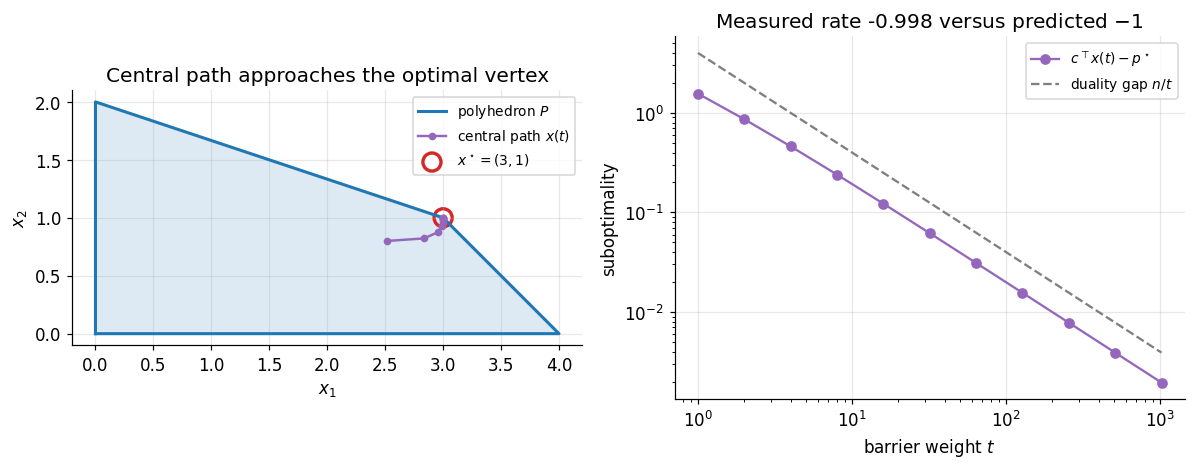

In [8]:
def center(A, b, c, t, x):
    """Newton's method on min t c^T x - sum(log x) s.t. Ax = b, from a strictly feasible x."""
    m, n = A.shape
    w = np.zeros(m)
    for _ in range(100):
        g = t * c - 1.0 / x
        K = np.block([[np.diag(1.0 / x**2), A.T], [A, np.zeros((m, m))]])
        sol = np.linalg.solve(K, np.concatenate([-g, np.zeros(m)]))
        dx, w = sol[:n], sol[n:]
        if -g @ dx < 1e-16:                      # Newton decrement squared
            break
        step = 1.0
        while (x + step * dx <= 0).any():
            step *= 0.5
        phi = lambda z: t * c @ z - np.log(z).sum()
        while phi(x + step * dx) > phi(x) + 0.25 * step * (g @ dx):
            step *= 0.5
        x = x + step * dx
    return x, w


p_star = -9.0
x_path = np.array([1.0, 1.0, 2.0, 2.0])          # strictly feasible: Ax = b, x > 0
ts = 2.0 ** np.arange(0, 11)
path, subopt, gap_err = [], [], []
for t in ts:
    x_path, w = center(A, b, c, t, x_path)
    y_t = -w / t
    path.append(x_path[:2].copy())
    subopt.append(float(c @ x_path - p_star))
    gap_err.append(abs(float(c @ x_path - b @ y_t) - A.shape[1] / t))
path = np.array(path)

print("     t     c^T x(t)-p*     |gap - n/t|")
for t, s, e in zip(ts, subopt, gap_err):
    print(f"{t:7.0f}    {s:.6e}    {e:.2e}")

slope = np.polyfit(np.log(ts[-5:]), np.log(subopt[-5:]), 1)[0]
print(f"\nmax |duality gap - n/t| over the path : {max(gap_err):.3e}  (identity, Section 7.2)")
print(f"measured rate d log(subopt)/d log t   : {slope:.4f}   predicted: -1")
assert max(gap_err) < 1e-8 and abs(slope + 1.0) < 0.05

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
ax = axes[0]
ax.fill(verts[:, 0], verts[:, 1], color="tab:blue", alpha=0.15)
ax.plot(np.append(verts[:, 0], verts[0, 0]), np.append(verts[:, 1], verts[0, 1]),
        color="tab:blue", lw=2, label="polyhedron $P$")
ax.plot(path[:, 0], path[:, 1], "o-", color="tab:purple", ms=4, lw=1.6, label="central path $x(t)$")
ax.scatter([3.0], [1.0], s=140, facecolor="none", edgecolor="tab:red", lw=2.2, label=r"$x^\star=(3,1)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Central path approaches the optimal vertex")
ax.set_aspect("equal")
ax.legend(fontsize=9)

ax = axes[1]
ax.loglog(ts, subopt, "o-", color="tab:purple", label=r"$c^\top x(t) - p^\star$")
ax.loglog(ts, A.shape[1] / ts, "--", color="tab:grey", label=r"duality gap $n/t$")
ax.set_xlabel("barrier weight $t$")
ax.set_ylabel("suboptimality")
ax.set_title(f"Measured rate {slope:.3f} versus predicted $-1$")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The duality gap reproduces $n/t$ to $10^{-8}$ at every $t$, confirming that the identity of Section 7.2 is exact rather than asymptotic, and the measured log-log slope of the suboptimality is within $0.05$ of the predicted $-1$. Geometrically, the path enters the polyhedron from the analytic center and bends into the optimal vertex — never visiting any other vertex on the way.

### 7.6 What breaks when a hypothesis is dropped

Two hypotheses carry real weight: $A \succ 0$ in the Schur complement lemma (Theorem 4.5) and $Q \succeq 0$ in the definition of a convex QP (Definition 3.3). The cell below drops each in turn and shows the breakage.

In [9]:
# (i) Schur complement with A only PSD, not PD.
M_bad = np.array([[0.0, 1.0], [1.0, 1.0]])
A_blk, B_blk, C_blk = M_bad[:1, :1], M_bad[:1, 1:], M_bad[1:, 1:]
S_pinv = C_blk - B_blk.T @ np.linalg.pinv(A_blk) @ B_blk
print("(i) dropping A > 0 in Theorem 4.5")
print(f"    pseudo-inverse Schur complement S = {S_pinv[0, 0]:.4f}  (>= 0, so the test 'passes')")
print(f"    eigenvalues of M                  = {np.linalg.eigvalsh(M_bad)}")
print(f"    but lambda_min(M) = {np.linalg.eigvalsh(M_bad)[0]:.6f} < 0, so M is NOT PSD")
assert S_pinv[0, 0] >= 0 and np.linalg.eigvalsh(M_bad)[0] < -1e-9

# (ii) QP with indefinite Q: the stationary point is a saddle and the value is unbounded below.
Q_bad = np.array([[1.0, 0.0], [0.0, -1.0]])
c_bad = np.array([0.0, 0.0])
x_stat = np.linalg.solve(Q_bad, -c_bad)
f = lambda z: 0.5 * z @ Q_bad @ z + c_bad @ z
d_down = np.array([0.0, 1.0])
vals = [f(x_stat + a * d_down) for a in [1.0, 10.0, 100.0, 1000.0]]
print("\n(ii) dropping Q >= 0 in Definition 3.3")
print(f"    stationary point x = {x_stat}, f(x) = {f(x_stat):.4f}, eigenvalues of Q = "
      f"{np.linalg.eigvalsh(Q_bad)}")
print(f"    f along the descent direction (0,1) at alpha = 1, 10, 100, 1000: {np.array(vals)}")
assert vals[-1] < vals[0] and vals[-1] < -1e5

(i) dropping A > 0 in Theorem 4.5
    pseudo-inverse Schur complement S = 1.0000  (>= 0, so the test 'passes')
    eigenvalues of M                  = [-0.618  1.618]
    but lambda_min(M) = -0.618034 < 0, so M is NOT PSD

(ii) dropping Q >= 0 in Definition 3.3
    stationary point x = [ 0. -0.], f(x) = 0.0000, eigenvalues of Q = [-1.  1.]
    f along the descent direction (0,1) at alpha = 1, 10, 100, 1000: [     -0.5     -50.    -5000.  -500000. ]


Case (i): the pseudo-inverse Schur complement is $+1 \ge 0$, yet $\lambda_{\min}(M) = (1-\sqrt5)/2 \approx -0.618$, so the equivalence of Theorem 4.5 genuinely fails once $A \succ 0$ is weakened — the missing ingredient is the range condition $\operatorname{range}(B) \subseteq \operatorname{range}(A)$. Case (ii): with an indefinite $Q$ the stationary point is a saddle and the objective runs to $-\infty$ along an eigenvector of the negative eigenvalue, so "quadratic objective" without $Q \succeq 0$ is not a QP in any useful sense.

## 8. Applications

### 8.1 Finance and operations research

The Markowitz mean-variance problem

$$
\min_{w} \ \tfrac{1}{2} w^\top \Sigma w \quad \text{subject to} \quad \mu^\top w = r, \quad \mathbf{1}^\top w = 1
$$

is exactly the equality-constrained QP of Theorem 4.4, so its solution is one KKT solve and its value function $r \mapsto \tfrac{1}{2}\sigma^2(r)$ is a parabola — the efficient frontier. The multipliers price the return target, which is the content of exercise L2.3.
Classical operations research runs on LP: production planning, blending, transportation and network flow, where the dual prices of Theorem 4.3 drive real decisions — which machine hour is worth buying, which nutrient constraint sets the diet cost (exercises L2.1 and L2.2).

### 8.2 Machine learning

- **Linear regression** is the unconstrained QP of Theorem 4.4: $(X^\top X)w = X^\top y$.
- **Ridge regression** adds $\tfrac{\lambda}{2}\lVert w\rVert_2^2$, shifting the Hessian to $X^\top X + \lambda I \succ 0$: always strictly convex, always uniquely solvable, better conditioned.
- **Hard-margin SVM** minimizes $\tfrac{1}{2}\lVert w\rVert_2^2$ subject to $y_i(w^\top x_i + b) \ge 1$, a QP whose Hessian is $\operatorname{diag}(I, 0) \succeq 0$; complementary slackness (Theorem 4.3, in its inequality form) is what makes only the margin-tight points *support* vectors.
- **Robust regression** with a bounded perturbation of the design matrix becomes an SOCP by the construction of Definition 3.4 (exercise L2.6).

### 8.3 Engineering, control, and combinatorics

- **Robust design.** Tolerancing, antenna and filter design under ellipsoidal parameter uncertainty are SOCPs; truss topology design is a classic SDP/SOCP family.
- **Control theory.** Lyapunov stability of $\dot{z} = Az$ is the LMI feasibility problem $A^\top P + PA \prec 0$, $P \succ 0$; $H_\infty$ synthesis and many observer designs are SDPs. This is the physical face of the PSD cone: an energy function decreasing along every trajectory.
- **Combinatorial relaxation.** The max-cut SDP of Definition 3.5 relaxes $x_i \in \{-1,1\}$ to unit vectors; rounding by a random hyperplane guarantees at least $0.878$ of the optimum in expectation (Goemans-Williamson), the flagship example of an SDP bounding an NP-hard problem. Exercise L3.3 solves the triangle case in closed form.
- **Quantum and statistical physics.** Density matrices are PSD with unit trace, so state estimation and energy minimization over quantum states are SDPs; moment relaxations of polynomial optimization (Lasserre) climb further up the same conic ladder.

## 9. Key Takeaways

1. If a standard-form LP over a nonempty feasible set attains its optimum, some extreme point attains it, so the search is finite (Theorem 4.1).
2. For any $A, b$, exactly one of "$Ax = b$ has a nonnegative solution" and "$A^\top y \le 0,\ b^\top y \gt 0$ is solvable" holds; infeasibility is certifiable (Theorem 4.2).
3. Every feasible primal-dual LP pair satisfies $b^\top y \le c^\top x$ with no hypotheses, and equality holds precisely when every product $x_j(c - A^\top y)_j$ vanishes (Theorem 4.3).
4. A convex QP with only equality constraints is one symmetric KKT solve, and the solution is globally optimal because $Q \succeq 0$ (Theorem 4.4).
5. With $A \succ 0$ — and only then — the block matrix $M$ is PSD exactly when its Schur complement is, which converts norm constraints into linear matrix inequalities (Theorem 4.5).
6. Under the standard inner products the nonnegative orthant, the second-order cone and the PSD cone are each self-dual, so conic primal and dual live in the same geometry (Theorem 4.6).
7. Conic weak duality $d^\star \le p^\star$ needs nothing but feasibility, while conic strong duality needs a Slater point; LP is the special case where polyhedrality supplies the qualification for free (Theorem 4.7).
8. $\text{LP} \subseteq \text{QP} \subseteq \text{SOCP} \subseteq \text{SDP}$, with each inclusion given by an explicit affine reformulation and the first two strict (Theorem 4.8).

## 10. References

| Result in this notebook | Source | Where |
|---|---|---|
| Definitions 3.1-3.5, Theorem 4.8 (standard forms and conversions) | Boyd & Vandenberghe, *Convex Optimization* | Ch. 4; App. A.5.5 for Schur complements |
| Theorem 4.1, Theorem 4.3 (fundamental theorem, LP duality) | Luenberger & Ye, *Linear and Nonlinear Programming*, 4th ed. | §2.4 (Thm 2.7), §4.2 |
| Theorem 4.2 (Farkas' lemma, separation proof) | Bertsimas & Tsitsiklis, *Introduction to Linear Optimization* | §4.6 (Thm 4.6) |
| Section 7.1 (simplex, degeneracy, anti-cycling) | Dantzig, *Linear Programming and Extensions* | Ch. 5-7 |
| Theorem 4.4, Section 7.2 (QP KKT systems, interior-point implementations) | Nocedal & Wright, *Numerical Optimization*, 2nd ed. | Ch. 16 (§16.1), Ch. 14 |
| Theorems 4.6-4.7 (conic duality, self-dual cones, self-concordance) | Ben-Tal & Nemirovski, *Lectures on Modern Convex Optimization* | Lect. 1-3; Thm 2.4.1 |
| Theorem 4.7 part 2 counterexamples (SDP duality gaps) | Vandenberghe & Boyd, "Semidefinite Programming," *SIAM Review* 38(1) | §4 |
| Section 8.1 (mean-variance portfolios) | Markowitz, "Portfolio Selection," *J. Finance* 7(1), 1952 | Whole paper |
| Section 8.3 (max-cut rounding, the $0.878$ constant) | Goemans & Williamson, *J. ACM* 42(6), 1995 | §3 (Thm 3.3) |

Suggested reading order: Boyd & Vandenberghe Ch. 4 for the taxonomy, Luenberger & Ye for polyhedral geometry and the fundamental theorem, Bertsimas & Tsitsiklis §4.6 for Farkas and duality, Nocedal & Wright for algorithms, then Ben-Tal & Nemirovski and the Vandenberghe-Boyd survey for the conic frontier.